# Week 2 - Day 5: Complete Exploratory Data Analysis (EDA)

## Objective

Perform a complete Exploratory Data Analysis (EDA) on the Titanic dataset, including descriptive statistics, univariate analysis, bivariate analysis, correlation analysis, and data storytelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../Week 1/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Descriptive Statistics

The descriptive statistics summarize the central tendency and variability of the numerical variables in the dataset.

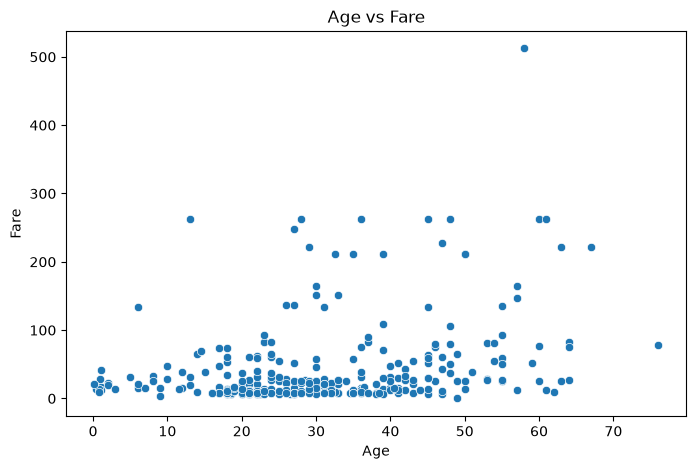

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare"
)

plt.title("Age vs Fare")
plt.show()

## Scatter Plot Analysis

The scatter plot helps visualize the relationship between passenger age and fare.

There is no strong linear relationship, although higher fares tend to include a few passengers across different age groups.

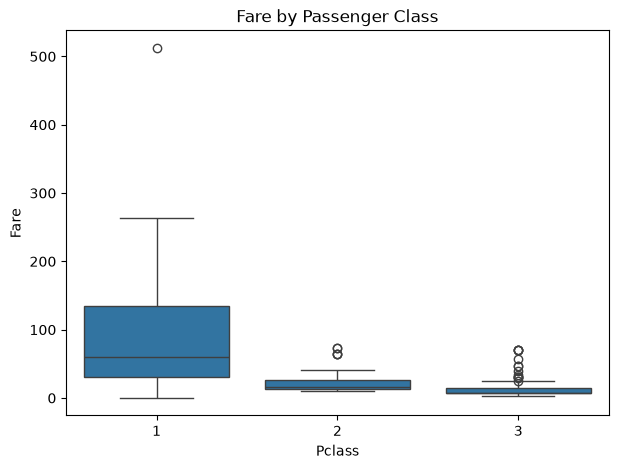

In [6]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare by Passenger Class")
plt.show()

## Grouped Box Plot Analysis

Passengers in higher classes generally paid higher fares.

The distribution also shows several outliers representing unusually expensive tickets.

In [7]:
corr = df.corr(numeric_only=True)

corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.023245,-0.026751,-0.034102,0.003818,0.043080,0.008211
Survived,-0.023245,1.000000,-0.108615,-0.000013,0.099943,0.159120,0.191514
Pclass,-0.026751,-0.108615,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.034102,-0.000013,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.003818,0.099943,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.043080,0.159120,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.337932,0.171539,0.230046,1.000000


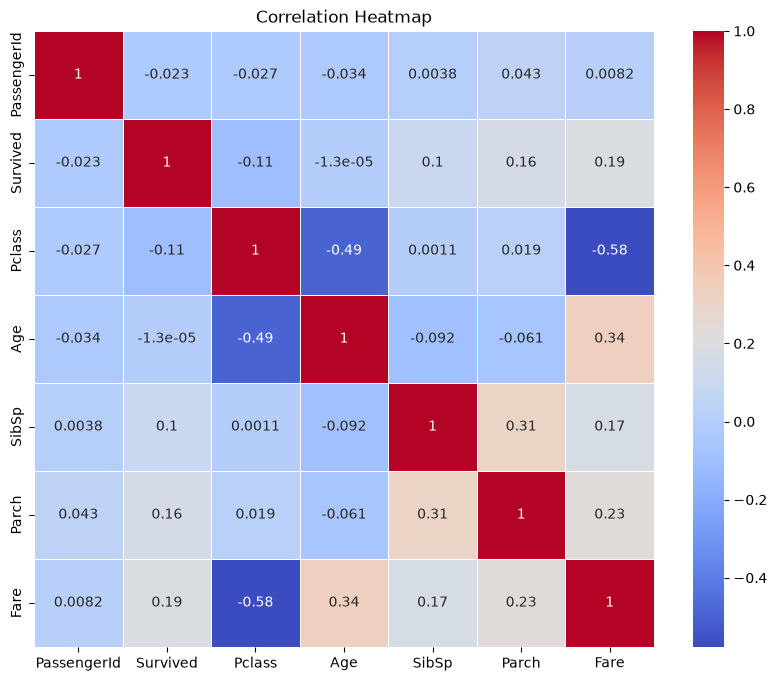

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

The correlation heatmap shows the strength and direction of relationships between numerical variables.

Positive values indicate variables that increase together, while negative values indicate inverse relationships.

Correlation helps identify useful features but does not imply causation.

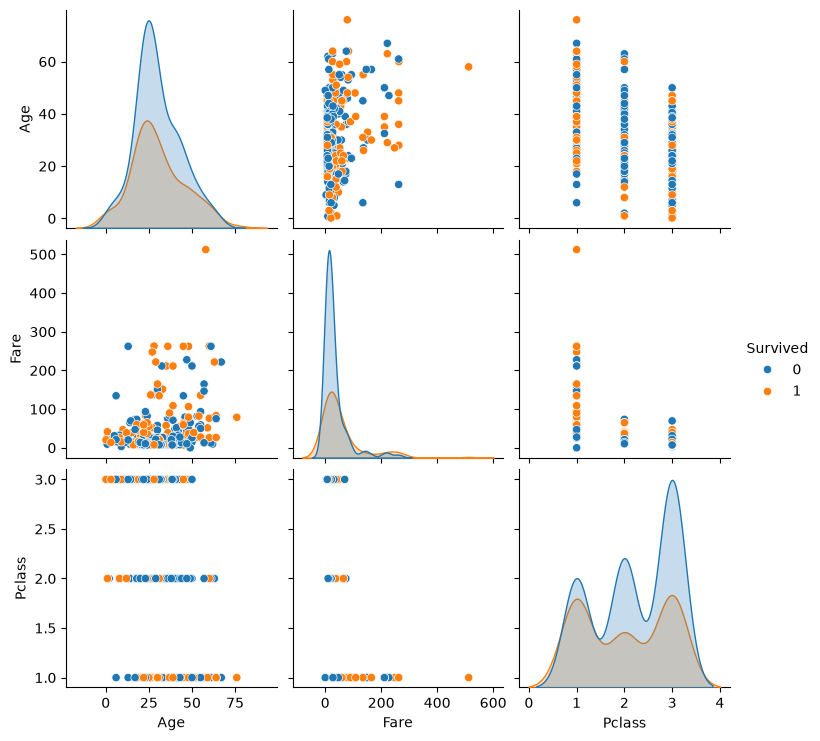

In [9]:
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]].dropna(),
    hue="Survived"
)

plt.show()

## Pairplot Analysis

The pairplot provides a quick overview of relationships between important numerical variables.

It also highlights how different survival outcomes are distributed across these variables.

In [10]:
corr["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.191514
Parch          0.159120
SibSp          0.099943
Age           -0.000013
PassengerId   -0.023245
Pclass        -0.108615
Name: Survived, dtype: float64

## Key Findings

- **Fare** has the strongest positive correlation with survival (**0.19**). Passengers who paid higher fares were slightly more likely to survive.
- **Parch** (parents/children aboard) has a weak positive correlation with survival (**0.16**), suggesting passengers traveling with close family members had a slightly higher chance of survival.
- **SibSp** (siblings/spouses aboard) also has a weak positive correlation (**0.10**) with survival.
- **Pclass** has a weak negative correlation (**-0.11**) with survival, indicating that passengers in lower classes were generally less likely to survive.
- **Age** has almost no correlation with survival (**≈ 0.00**), suggesting little linear relationship in this dataset.

# Data Storytelling

The Titanic dataset contains information about passengers, including demographic details, ticket information, and survival status.

The exploratory analysis revealed differences in passenger characteristics, detected outliers, and identified relationships between variables.

Passenger class and fare appear to be important predictors of survival, while age has a weaker relationship.

Overall, this EDA provides a strong foundation for future preprocessing and machine learning modeling.